c:\Users\Ramya Sankar\AppData\Local\Programs\Python\Python311\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm



Skipped subjects:
  S03: File too short: need >= 1740s, have 1436.8s

Feature DF shape: (54, 12) Subjects: 27
  Subject    Class  mean_tonic_eda  phasic_mean_risetime  \
0     F01  AEROBIC       -0.113848              1.056452   
1     F01     REST        0.008537              1.678571   
2     F02  AEROBIC       -0.035506              1.642857   
3     F02     REST        0.014276              1.125000   
4     F03  AEROBIC       -0.007929              1.185484   

   phasic_mean_recoverytime  max_scr_interval  scr_peaks_per_min  kurtosis  \
0                  0.766129             11.50          10.333333 -0.384507   
1                  0.750000             29.75           3.500000  4.385169   
2                  1.142857             26.75           4.666667  1.822778   
3                  1.125000              9.00           1.000000  3.161582   
4                  0.741935             12.00          10.666667  0.157959   

   skewness  peak_amplitude       IQR  freq_peak_amplitude 

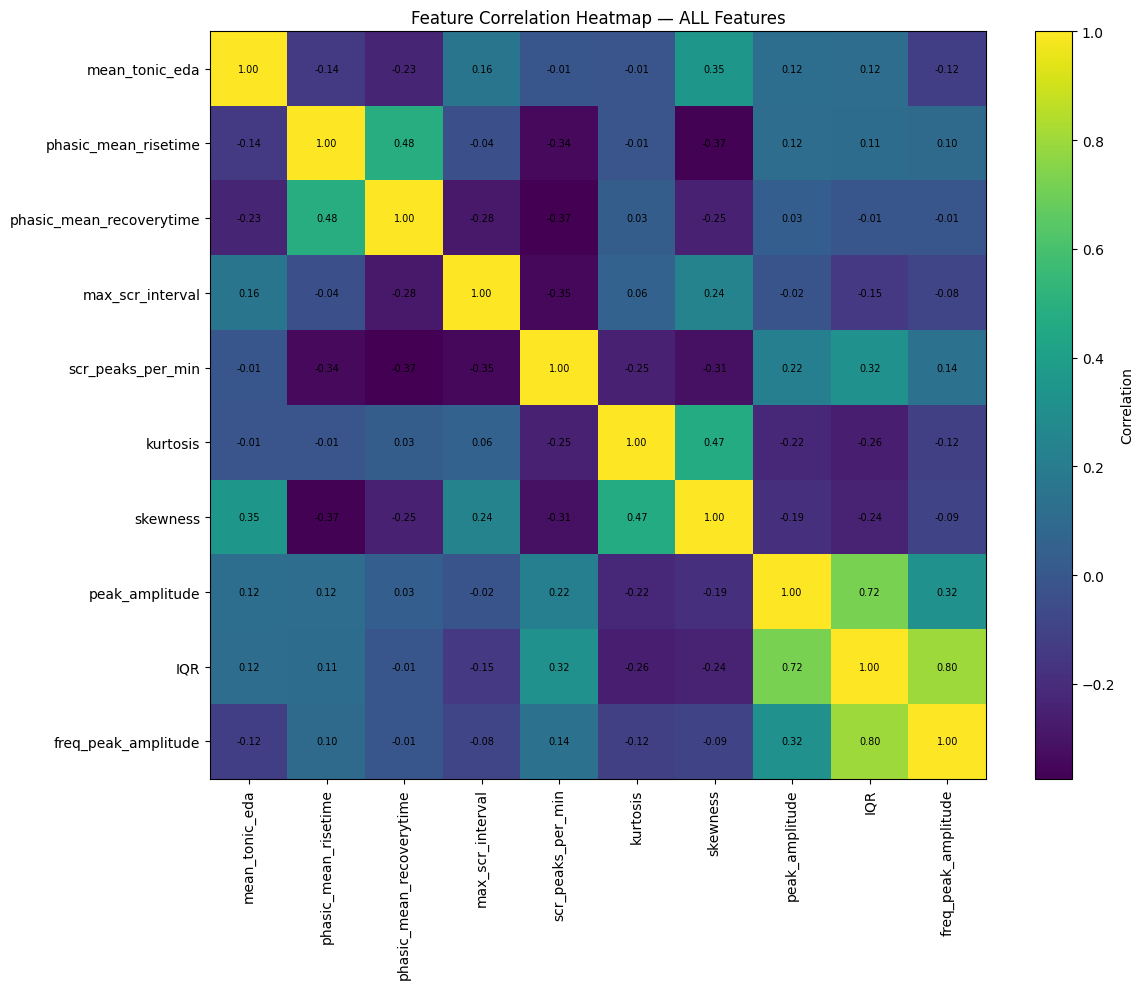

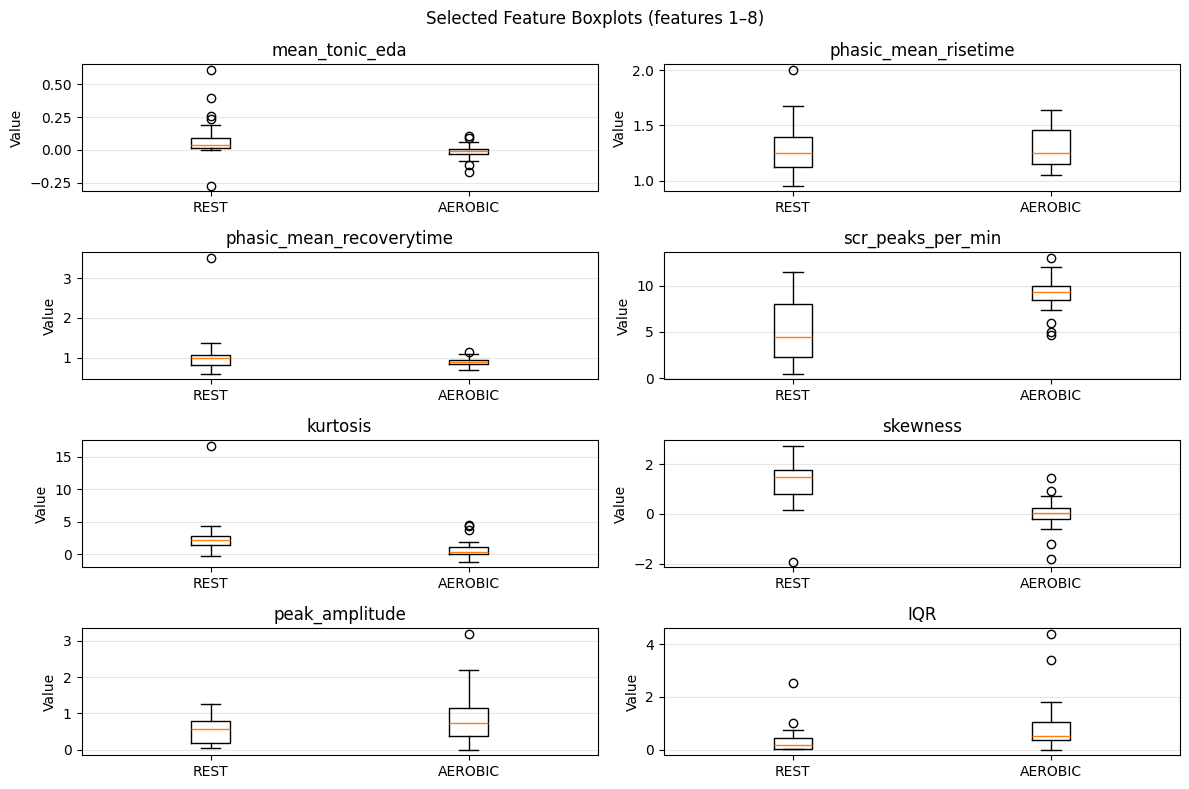


RFE selected features (TOP 8):
['mean_tonic_eda', 'phasic_mean_risetime', 'phasic_mean_recoverytime', 'scr_peaks_per_min', 'kurtosis', 'skewness', 'peak_amplitude', 'IQR']

RFE ranking (1 = selected):
                 feature  ranking
          mean_tonic_eda        1
    phasic_mean_risetime        1
phasic_mean_recoverytime        1
       scr_peaks_per_min        1
                skewness        1
                kurtosis        1
          peak_amplitude        1
                     IQR        1
        max_scr_interval        2
     freq_peak_amplitude        3


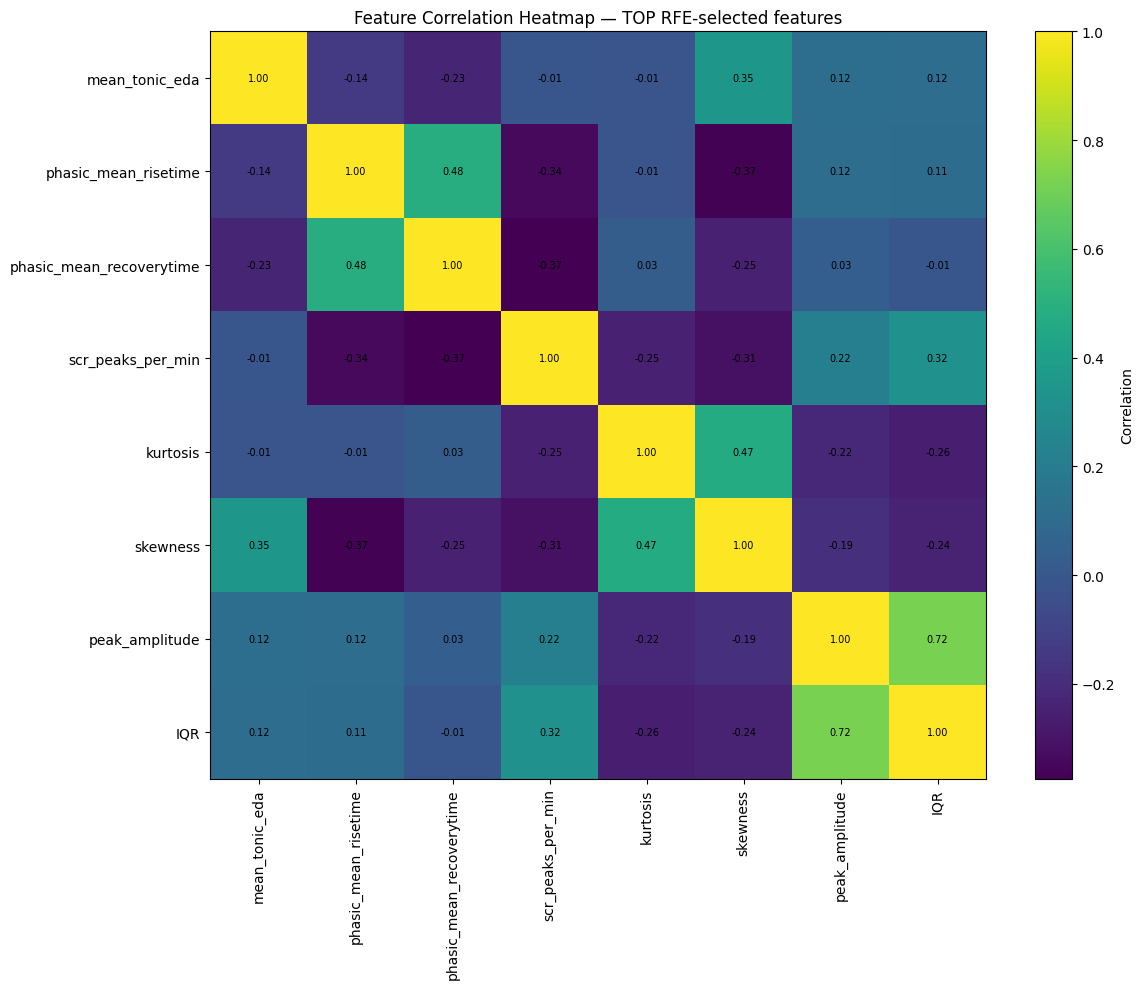

Low-correlation feature count: 9
Dropped due to |r| ≥ 0.8: ['freq_peak_amplitude']


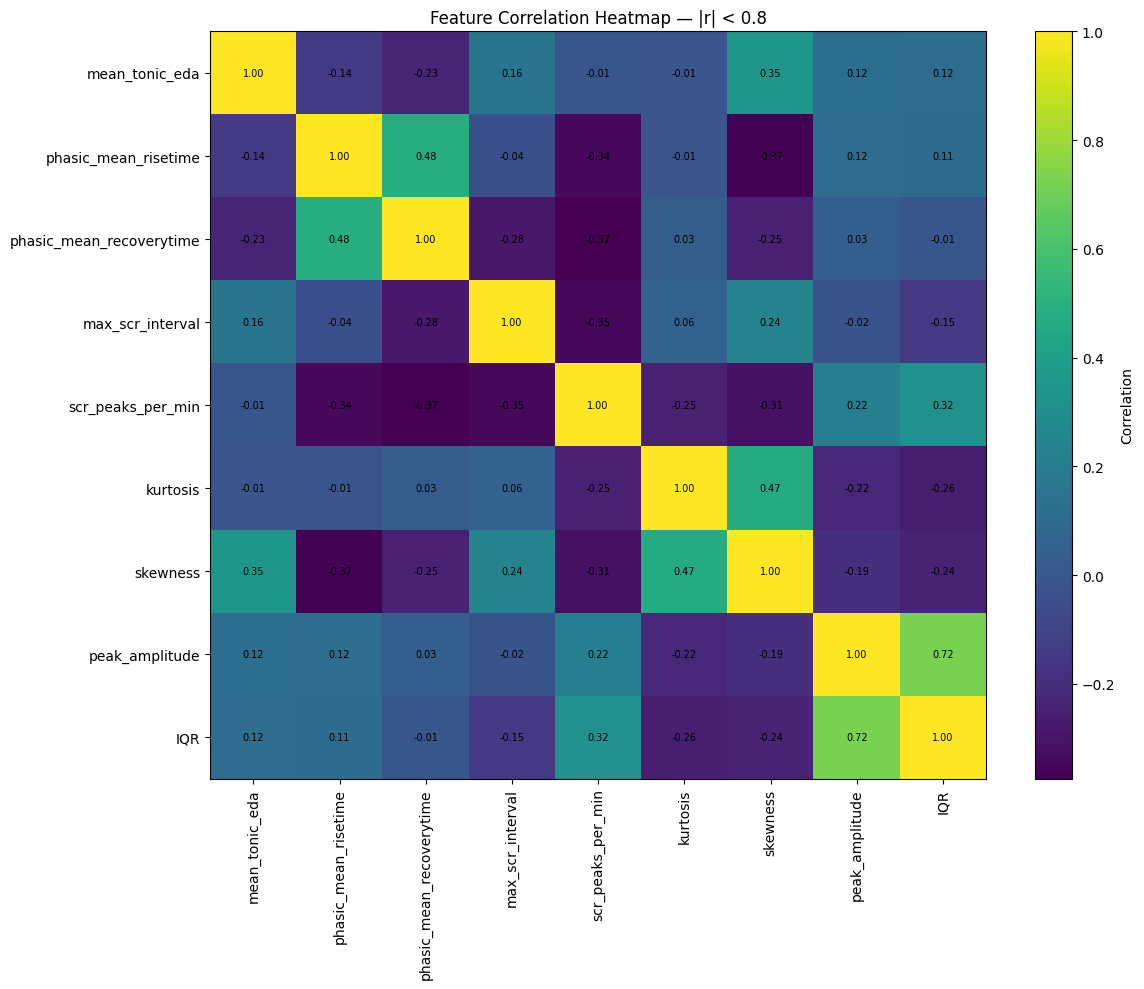


LOSO Results (Mean ± SD):
             Model  Accuracy_Mean  Accuracy_SD  Precision_Mean  Precision_SD  Recall_Mean  Recall_SD  F1_Mean  F1_SD  Folds  N  Features
    LDA_autoshrink           0.89         0.25            0.89          0.25         0.96       0.19     0.91   0.22     27 54         8
           LDA_std           0.85         0.27            0.85          0.27         0.96       0.19     0.89   0.23     27 54         8
        ExtraTrees           0.87         0.30            0.87          0.30         0.93       0.27     0.89   0.28     27 54         8
        LDA_robust           0.85         0.27            0.85          0.27         0.96       0.19     0.89   0.23     27 54         8
                LR           0.89         0.29            0.87          0.33         0.89       0.32     0.88   0.32     27 54         8
       ExtraTreesq           0.85         0.30            0.85          0.30         0.93       0.27     0.88   0.28     27 54         8
              

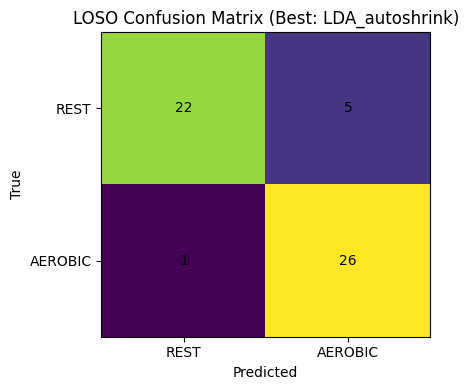


BEST 5-FOLD: kNN5
CM_5FOLD:
 [[24  3]
 [ 2 25]]


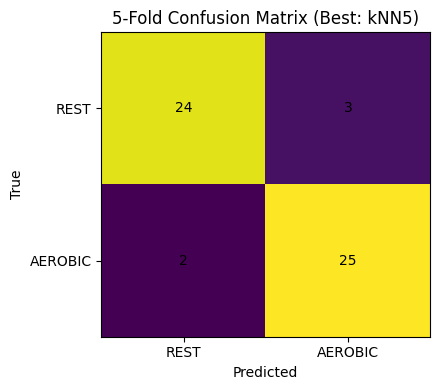

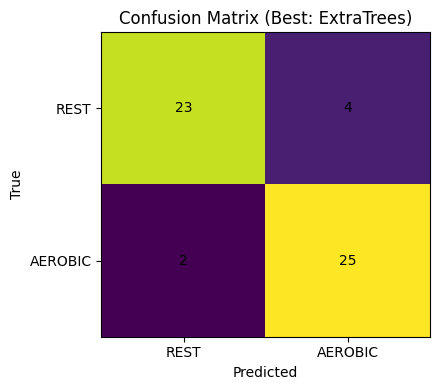


LOSO Results (low-correlation |r| < 0.8):
             Model  Accuracy_Mean  Accuracy_SD  Precision_Mean  Precision_SD  Recall_Mean  Recall_SD  F1_Mean  F1_SD  Folds  N  Features
    LDA_autoshrink           0.87         0.26            0.87          0.26         0.96       0.19     0.90   0.22     27 54         9
           LDA_std           0.85         0.27            0.85          0.27         0.96       0.19     0.89   0.23     27 54         9
        ExtraTrees           0.87         0.30            0.87          0.30         0.93       0.27     0.89   0.28     27 54         9
        LDA_robust           0.85         0.27            0.85          0.27         0.96       0.19     0.89   0.23     27 54         9
       ExtraTreesq           0.85         0.30            0.85          0.30         0.93       0.27     0.88   0.28     27 54         9
     LDA_pt3shrink           0.83         0.31            0.81          0.34         0.89       0.32     0.84   0.33     27 54         

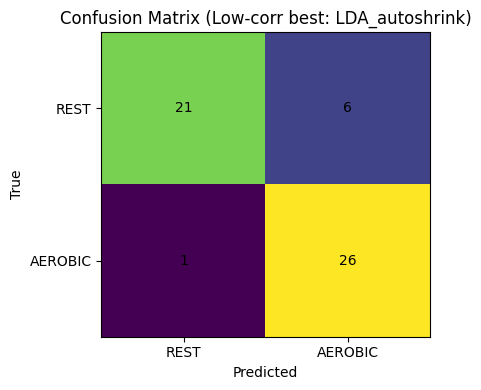

In [1]:
#!/usr/bin/env python3
import os, glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import shap

from biosppy import storage
from scipy.signal import butter, filtfilt, welch, find_peaks
from scipy.stats import kurtosis, skew, iqr

from sklearn.model_selection import LeaveOneGroupOut, StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.feature_selection import RFE
from sklearn.metrics import accuracy_score, balanced_accuracy_score, recall_score, precision_score, f1_score, confusion_matrix
from sklearn.preprocessing import QuantileTransformer

from sklearn.linear_model import LogisticRegression
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import ExtraTreesClassifier

from lightgbm import LGBMClassifier
from xgboost import XGBClassifier

import warnings
warnings.filterwarnings("ignore", category=Warning)
warnings.filterwarnings("ignore", category=DeprecationWarning)
warnings.filterwarnings("ignore", category=RuntimeWarning)
warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", message="nperseg*")

warnings.filterwarnings("ignore", message=r".*nperseg.*", category=UserWarning, module=r"scipy\.signal")

# -----------------------------
# Signal processing helpers
# -----------------------------
def _filtfilt_safe(b, a, x):
    x = np.asarray(x, dtype=float).squeeze()
    padlen = 3 * (max(len(a), len(b)) - 1)
    if len(x) <= padlen:
        raise ValueError(f"Segment too short for filtfilt: len={len(x)} <= padlen={padlen}")
    return filtfilt(b, a, x)

def minmax_scale(x, eps=1e-8):
    x = np.asarray(x, dtype=float).squeeze()
    if x.size == 0:
        return x
    return (x - np.min(x)) / (np.max(x) - np.min(x) + eps)

def butter_bandpass(x, fs, low=0.01, high=1.0, order=4):
    nyq = 0.5 * fs
    if not (0 < low < high < nyq):
        raise ValueError(f"Bad bandpass cutoffs: low={low}, high={high}, nyq={nyq}")
    b, a = butter(order, [low/nyq, high/nyq], btype="band")
    return _filtfilt_safe(b, a, x)

def butter_lowpass(x, fs, cutoff=0.05, order=4):
    nyq = 0.5 * fs
    if not (0 < cutoff < nyq):
        raise ValueError(f"Bad lowpass cutoff: cutoff={cutoff}, nyq={nyq}")
    b, a = butter(order, cutoff/nyq, btype="low")
    return _filtfilt_safe(b, a, x)

def butter_highpass(x, fs, cutoff=0.05, order=4):
    nyq = 0.5 * fs
    if not (0 < cutoff < nyq):
        raise ValueError(f"Bad highpass cutoff: cutoff={cutoff}, nyq={nyq}")
    b, a = butter(order, cutoff/nyq, btype="high")
    return _filtfilt_safe(b, a, x)

def bandpower(freqs, psd, fmin, fmax):
    mask = (freqs >= fmin) & (freqs <= fmax)
    if np.sum(mask) < 2:
        return 0.0
    return float(np.trapezoid(psd[mask], freqs[mask]))

# -----------------------------
# Feature extraction
# -----------------------------
def extract_features(x, fs):
    x = np.asarray(x, dtype=float).squeeze()
    eps = 1e-8
    if len(x) < 20:
        raise ValueError(f"Segment too short for features: len={len(x)}")

    tonic = butter_lowpass(x, fs, 0.05)
    phasic = butter_bandpass(x, fs, low=0.1, high=0.5, order=4)

    prom = np.std(phasic) if np.std(phasic) > 0 else 1e-8
    peaks, _ = find_peaks(phasic, prominence=prom)
    peak_amps = phasic[peaks] if len(peaks) else np.array([0.0])

    rise_times, recovery_times = [], []
    # for p in peaks:
    #     left = max(0, p - int(2 * fs))
    #     right = min(len(phasic) - 1, p + int(4 * fs))
    #     rise_times.append((p - left) / fs)
    #     recovery_times.append((right - p) / fs)
    for p in peaks:
    # ---------- BASELINE ----------
        lb = max(0, p - int(10 * fs))
        baseline = np.median(phasic[lb:p]) if p > lb else phasic[p]

        peak_val = phasic[p]
        amp = peak_val - baseline
        if amp <= 1e-8:
            continue

    # ---------- RISE TIME (onset → peak) ----------
        onset_thresh = baseline + 0.05 * amp
        i = p
        while i > lb and phasic[i] > onset_thresh:
            i -= 1
        rise_times.append((p - i) / fs)
    
    # ---------- RECOVERY TIME (peak → 50% decay) ----------
        rec_thresh = baseline + 0.5 * amp
        ra = min(len(phasic) - 1, p + int(15 * fs))
        j = p
        while j < ra and phasic[j] > rec_thresh:
            j += 1
        recovery_times.append((j - p) / fs)
    
    scr_interval = np.diff(peaks) / fs if len(peaks) >= 2 else np.array([0.0])
    scr_interval_rmssd = float(np.sqrt(np.mean(np.diff(scr_interval) ** 2))) if len(scr_interval) > 2 else 0.0

    duration_sec = len(x) / fs
    peak_density = float(len(peaks) / (duration_sec + eps))
    scr_peaks_per_min = float(len(peaks) / ((duration_sec / 60) + eps))

    nperseg = min(256, len(x))
    freqs, psd = welch(x, fs=fs, window="hann", nperseg=nperseg, scaling="density")

    psd_peaks, _ = find_peaks(psd)
    psd_peak_amps = psd[psd_peaks] if len(psd_peaks) else np.array([0.0])

    def second_largest(arr):
        arr = np.asarray(arr, dtype=float)
        if len(arr) < 2:
            return 0.0
        return float(np.partition(arr, -2)[-2])

    return {
        #"mean_raw_eda": float(np.mean(x)),
        "mean_tonic_eda": float(np.mean(tonic)),
        #"mean_phasic_eda": float(np.mean(phasic)),
        #"tonic_variance": float(np.var(tonic)),
        #"phasic_variance": float(np.var(phasic)),
        "phasic_mean_risetime": float(np.mean(rise_times)) if len(rise_times) else 0.0,
        "phasic_mean_recoverytime": float(np.mean(recovery_times)) if len(recovery_times) else 0.0,
        "max_scr_interval": float(np.max(scr_interval)),
        #"mean_scr_interval": float(np.mean(scr_interval)),
        #"scr_interval_rmssd": scr_interval_rmssd,
        #"peak_density": peak_density,
        "scr_peaks_per_min": scr_peaks_per_min,
        "kurtosis": float(kurtosis(x)),
        "skewness": float(skew(x)),
        "peak_amplitude": float(np.max(peak_amps)),
        #"2nd_amplitude": second_largest(peak_amps),
        "IQR": float(iqr(x)),
        "freq_peak_amplitude": float(np.max(psd_peak_amps)) if len(psd_peak_amps) else 0.0,
        #"freq_2nd_amp": second_largest(psd_peak_amps), #high correlation with freq_peak_amplitude and IQR
        #"psd_bandpower": bandpower(freqs, psd, 0.01, 1.0)#high correlation with freq_peak_amplitude and IQR
    }
# -----------------------------
# Tonic sequence (trend) features
# -----------------------------
def sliding_windows(x, fs, win_sec=30, step_sec=5):
    x = np.asarray(x, dtype=float).squeeze()
    win = int(win_sec * fs)
    step = int(step_sec * fs)
    if len(x) < win or win <= 0 or step <= 0:
        return []
    return [x[i:i+win] for i in range(0, len(x) - win + 1, step)]

def safe_slope(y):
    y = np.asarray(y, dtype=float)
    if len(y) < 2 or np.allclose(np.std(y), 0):
        return 0.0
    t = np.arange(len(y), dtype=float)
    # slope = cov(t,y)/var(t)
    return float(np.cov(t, y, ddof=0)[0, 1] / (np.var(t) + 1e-12))

def extract_tonic_sequence_features(x, fs, win_sec=30, step_sec=5):
    """
    Sequence features computed within THIS segment only (REST or AEROBIC).
    Returns 4 features:
      tonic_ratio_up
      tonic_mean_slope
      tonic_mean_late_minus_early
      activation_duration
    """
    x = np.asarray(x, dtype=float).squeeze()

    # tonic estimate (same cutoff you use elsewhere)
    tonic = butter_lowpass(x, fs=fs, cutoff=0.05)

    wins = sliding_windows(tonic, fs, win_sec=win_sec, step_sec=step_sec)
    if len(wins) == 0:
        return {
            "tonic_ratio_up": 0.0,
            "tonic_mean_slope": 0.0,
            "tonic_mean_late_minus_early": 0.0,
            "activation_duration": 0.0,
        }

    tonic_means = np.array([np.mean(w) for w in wins], dtype=float)
    tonic_means = np.nan_to_num(tonic_means, nan=0.0, posinf=0.0, neginf=0.0)

    # baseline defined within-segment to avoid cross-subject bias
    baseline = float(np.median(tonic_means))

    tonic_ratio_up = float(np.mean(tonic_means > baseline))
    tonic_mean_slope = safe_slope(tonic_means)

    q = max(1, len(tonic_means) // 4)
    early_mean = float(np.mean(tonic_means[:q]))
    late_mean  = float(np.mean(tonic_means[-q:]))
    tonic_mean_late_minus_early = float(late_mean - early_mean)

    # longest consecutive run above baseline (in seconds)
    above = tonic_means > baseline
    max_run = run = 0
    for v in above:
        if v:
            run += 1
            max_run = max(max_run, run)
        else:
            run = 0
    activation_duration = float(max_run * step_sec)

    return {
            # The following tonic sequence features were REMOVED because they act as protocol-dependent class proxies under fixed REST→AEROBIC segmentation:
            # tonic_mean_late_minus_early: encodes early vs late segment timing
            # activation_duration: reflects sustained tonic elevation tied to task phase
            # tonic_ratio_up: can leak class information depending on baseline definition
            # These features artificially inflate LOSO accuracy and were excluded to prevent temporal leakage and preserve physiological validity.
            # "tonic_ratio_up": tonic_ratio_up,
            #"tonic_mean_slope": tonic_mean_slope,
            # "tonic_mean_late_minus_early": tonic_mean_late_minus_early,
            # "activation_duration": activation_duration,
}
# -----------------------------
# Build DF (2 rows per subject: REST/AEROBIC)
# -----------------------------
def build_feature_df(folder_path, rest_sec=120, aerobic_start_sec=1560, aerobic_end_sec=1740):
    files = sorted(glob.glob(os.path.join(folder_path, "*.txt")))
    rows, skipped = [], []

    for fp in files:
        subject = os.path.splitext(os.path.basename(fp))[0]
        try:
            signal, meta = storage.load_txt(fp)
            fs = 4.0
            if isinstance(meta, dict):
                fs = float(meta.get("sampling_rate", meta.get("sr", fs)))

            signal = np.asarray(signal, dtype=float).squeeze()
            if len(signal) == 0:
                raise ValueError("Empty signal")

            need_end = int(aerobic_end_sec * fs)
            if len(signal) < need_end:
                raise ValueError(f"File too short: need >= {aerobic_end_sec}s, have {len(signal)/fs:.1f}s")

            signal_filt = butter_bandpass(signal, fs=fs, low=0.01, high=1.0, order=4)
            #signal_filt = minmax_scale(signal_filt)

            rest = signal_filt[:int(rest_sec * fs)]
            aerobic = signal_filt[int(aerobic_start_sec * fs):int(aerobic_end_sec * fs)]

            #rows.append({"Subject": subject, "Class": "REST", **extract_features(rest, fs)})
            #rows.append({"Subject": subject, "Class": "AEROBIC", **extract_features(aerobic, fs)})
            rest_feats = extract_features(rest, fs)
            rest_seq   = extract_tonic_sequence_features(rest, fs, win_sec=30, step_sec=5)
            rows.append({"Subject": subject, "Class": "REST", **rest_feats, **rest_seq})

            aer_feats = extract_features(aerobic, fs)
            aer_seq   = extract_tonic_sequence_features(aerobic, fs, win_sec=30, step_sec=5)
            rows.append({"Subject": subject, "Class": "AEROBIC", **aer_feats, **aer_seq})
        except Exception as e:
            skipped.append((subject, str(e)))

    df = pd.DataFrame(rows).sort_values(["Subject", "Class"]).reset_index(drop=True)
    return df, skipped

# -----------------------------
# Plot heatmap
# -----------------------------
def plot_corr_heatmap(corr, title="Feature Correlation Heatmap", annotate=True):
    fig, ax = plt.subplots(figsize=(12, 10))
    im = ax.imshow(corr.values, aspect="auto") 
    ax.set_title(title)
    ax.set_xticks(range(len(corr.columns)))
    ax.set_yticks(range(len(corr.index)))
    ax.set_xticklabels(corr.columns, rotation=90)
    ax.set_yticklabels(corr.index)
    for i in range(len(corr)):
        for j in range(len(corr)):
            ax.text(j, i, f"{corr.values[i, j]:.2f}",
                    ha="center", va="center", fontsize=7)

    cbar = fig.colorbar(im, ax=ax)
    cbar.set_label("Correlation")
    plt.tight_layout()
    plt.show()

# -----------------------------
# LOSO eval
# -----------------------------
def loso_eval(models, X, y, groups, selected_features=None):
    logo = LeaveOneGroupOut()
    results = []
    confs = {}

    for name, model in models.items():
        accs, baccs, precs, recs, f1s = [], [], [], [], []
        y_true_all, y_pred_all = [], []

        for train_idx, test_idx in logo.split(X, y, groups=groups):
            X_train, X_test = X[train_idx], X[test_idx]
            y_train, y_test = y[train_idx], y[test_idx]

            model.fit(X_train, y_train)
            y_pred = model.predict(X_test)

            # pooled for confusion matrix
            y_true_all.extend(y_test.tolist())
            y_pred_all.extend(y_pred.tolist())

            # per-fold metrics (so we can compute SD)
            accs.append(accuracy_score(y_test, y_pred))
            baccs.append(balanced_accuracy_score(y_test, y_pred))
            precs.append(precision_score(y_test, y_pred, zero_division=0))
            recs.append(recall_score(y_test, y_pred, zero_division=0))
            f1s.append(f1_score(y_test, y_pred, zero_division=0))

        confs[name] = confusion_matrix(y_true_all, y_pred_all, labels=[0, 1])

        results.append({
            "Model": name,
            "Accuracy_Mean": float(np.mean(accs)),
            "Accuracy_SD": float(np.std(accs, ddof=1)) if len(accs) > 1 else 0.0,
            #"BalancedAcc_Mean": float(np.mean(baccs)),
            #"BalancedAcc_SD": float(np.std(baccs, ddof=1)) if len(baccs) > 1 else 0.0,
            "Precision_Mean": float(np.mean(precs)),
            "Precision_SD": float(np.std(precs, ddof=1)) if len(precs) > 1 else 0.0,
            "Recall_Mean": float(np.mean(recs)),
            "Recall_SD": float(np.std(recs, ddof=1)) if len(recs) > 1 else 0.0,
            "F1_Mean": float(np.mean(f1s)),
            "F1_SD": float(np.std(f1s, ddof=1)) if len(f1s) > 1 else 0.0,
            "Folds": int(len(accs)),
            "N": int(len(y_true_all)),
            "Features": int(selected_features if selected_features is not None else X.shape[1]),
        })
    # Sort by Accuracy_Mean  
    return pd.DataFrame(results).sort_values("F1_Mean", ascending=False), confs
# -----------------------------
# 5-fold eval
# -----------------------------
def stratified_5fold_eval(models, X, y, selected_features=None, seed=42):
    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=seed)
    results = []
    confs = {}

    for name, model in models.items():
        accs, baccs, precs, recs, f1s = [], [], [], [], []
        y_true_all, y_pred_all = [], []

        for train_idx, test_idx in skf.split(X, y):
            X_train, X_test = X[train_idx], X[test_idx]
            y_train, y_test = y[train_idx], y[test_idx]

            model.fit(X_train, y_train)
            y_pred = model.predict(X_test)

            y_true_all.extend(y_test.tolist())
            y_pred_all.extend(y_pred.tolist())

            accs.append(accuracy_score(y_test, y_pred))
            baccs.append(balanced_accuracy_score(y_test, y_pred))
            precs.append(precision_score(y_test, y_pred, zero_division=0))
            recs.append(recall_score(y_test, y_pred, zero_division=0, pos_label=1))
            f1s.append(f1_score(y_test, y_pred, zero_division=0))

        confs[name] = confusion_matrix(y_true_all, y_pred_all, labels=[0, 1])

        results.append({
            "Model": name,
            "Accuracy_Mean": float(np.mean(accs)),
            "Accuracy_SD": float(np.std(accs, ddof=1)) if len(accs) > 1 else 0.0,
            #"BalancedAcc_Mean": float(np.mean(baccs)),
            #"BalancedAcc_SD": float(np.std(baccs, ddof=1)) if len(baccs) > 1 else 0.0,
            "Precision_Mean": float(np.mean(precs)),
            "Precision_SD": float(np.std(precs, ddof=1)) if len(precs) > 1 else 0.0,
            "Recall_Mean": float(np.mean(recs)),
            "Recall_SD": float(np.std(recs, ddof=1)) if len(recs) > 1 else 0.0,
            "F1_Mean": float(np.mean(f1s)),
            "F1_SD": float(np.std(f1s, ddof=1)) if len(f1s) > 1 else 0.0,
            "Folds": 5,
            "N": int(len(y_true_all)),
            "Features": int(selected_features if selected_features is not None else X.shape[1]),
        })

    return pd.DataFrame(results).sort_values("F1_Mean", ascending=False), confs
# -----------------------------
# Plot boxplots
# -----------------------------
def plot_selected_feature_boxplots(feature_df, selected_features, class_col="Class", nrows=4, ncols=2):
    """
    Draw boxplots for selected features in 2x2 pages.
    Each feature is plotted as two boxes (REST vs AEROBIC).
    """
    if len(selected_features) == 0:
        print("No selected features to plot.")
        return

    # Ensure class order is consistent
    class_order = ["REST", "AEROBIC"]
    classes = [c for c in class_order if c in feature_df[class_col].unique()]

    per_page = nrows * ncols
    total = len(selected_features)

    for start in range(0, total, per_page):
        chunk = selected_features[start:start + per_page]
        fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(12, 8))
        axes = np.array(axes).reshape(-1)

        for ax_i, feat in enumerate(chunk):
            ax = axes[ax_i]

            data = []
            for cls in classes:
                vals = feature_df.loc[feature_df[class_col] == cls, feat].values
                data.append(vals)

            ax.boxplot(data, labels=classes, showfliers=True)
            ax.set_title(feat)
            ax.set_ylabel("Value")
            ax.grid(True, axis="y", alpha=0.3)

        # Turn off unused axes on last page
        for j in range(len(chunk), len(axes)):
            axes[j].axis("off")

        fig.suptitle(f"Selected Feature Boxplots (features {start+1}–{min(start+per_page, total)})")
        plt.tight_layout()
        plt.show()
# -----------------------------
# MAIN
# -----------------------------
def main():
    folder_path = r"C:\Users\Ramya Sankar\Downloads\EDA_Files\Wearable_Dataset\AEROBIC"
    feature_df, skipped = build_feature_df(folder_path)

    if skipped:
        print("\nSkipped subjects:")
        for sid, reason in skipped:
            print(f"  {sid}: {reason}")

    print("\nFeature DF shape:", feature_df.shape, "Subjects:", feature_df["Subject"].nunique())
    print(feature_df.head())
 
    # ============================================================
    # FULL FEATURE TABLE (all features, 2 rows per subject)
    # ============================================================
    pd.set_option("display.max_columns", None)
    pd.set_option("display.width", 200)

    print("\nFULL FEATURE TABLE (sorted by Class, then Subject):")
    print(
        feature_df
        .sort_values(["Class", "Subject"])
        .to_string(index=False)
    )

    # y / groups
    y = (feature_df["Class"] == "AEROBIC").astype(int).values
    groups = feature_df["Subject"].values

    # ALL feature columns
    feature_cols = [c for c in feature_df.columns if c not in ["Subject", "Class"]]
    X_df = feature_df[feature_cols].copy()
    X = X_df.values

    # Heatmap (ALL features)
    corr_all = X_df.corr()
    plot_corr_heatmap(corr_all, title="Feature Correlation Heatmap — ALL Features", annotate=True)

    # RFE top K
    k = 8
    rfe_est = LogisticRegression(max_iter=5000, solver="liblinear")
    rfe_pipeline = Pipeline(steps=[
        ("impute", SimpleImputer(strategy="median")),
        ("scale", StandardScaler()),
        ("rfe", RFE(estimator=rfe_est, n_features_to_select=k))
    ])

    rfe_pipeline.fit(X, y)
    support = rfe_pipeline.named_steps["rfe"].support_
    selected = [f for f, keep in zip(feature_cols, support) if keep]
    
    #Boxplots of ALL selected features (2x2 pages)
    plot_selected_feature_boxplots(feature_df, selected, class_col="Class", nrows=4, ncols=2) 

    ranking = rfe_pipeline.named_steps["rfe"].ranking_
    ranking_df = pd.DataFrame({"feature": feature_cols, "ranking": ranking}).sort_values("ranking")

    print("\nRFE selected features (TOP 8):")
    print(selected)
    print("\nRFE ranking (1 = selected):")
    print(ranking_df.to_string(index=False))

    # Heatmap (TOP 8)
    corr_top = X_df[selected].corr()
    plot_corr_heatmap(corr_top, title="Feature Correlation Heatmap — TOP RFE-selected features", annotate=True)
    # -----------------------------
    # Heatmap: features with |r| < 0.8 (redundancy check)
    # -----------------------------
    corr_abs = X_df.corr().abs()

    upper = corr_abs.where(
        np.triu(np.ones(corr_abs.shape), k=1).astype(bool)
    )

    to_drop = [col for col in upper.columns if any(upper[col] >= 0.8)]
    low_corr_features = [c for c in X_df.columns if c not in to_drop]

    print(f"Low-correlation feature count: {len(low_corr_features)}")
    print("Dropped due to |r| ≥ 0.8:", to_drop)

    corr_low = X_df[low_corr_features].corr()

    plot_corr_heatmap(
        corr_low,
        title="Feature Correlation Heatmap — |r| < 0.8",
        annotate=True
    )
    # Use ONLY selected features for modeling
    X_sel = X_df[selected].values

    models = {
        "LR": Pipeline([
            ("impute", SimpleImputer(strategy="median")),
            ("scale", RobustScaler()),
            ("clf", LogisticRegression(C=1, max_iter=5000, solver="liblinear", class_weight="balanced"))
        ]),
        "LR3": Pipeline([
            ("impute", SimpleImputer(strategy="median")),
            ("scale", RobustScaler()),
            ("clf", LogisticRegression(C=3, max_iter=5000, solver="liblinear", class_weight="balanced"))
        ]),
        "LDA_autoshrink": Pipeline([
            ("impute", SimpleImputer(strategy="median")),
            ("scale", RobustScaler()),
            ("clf", LinearDiscriminantAnalysis(solver="lsqr", shrinkage="auto"))
        ]),
        "LDA_pt3shrink": Pipeline([
            ("impute", SimpleImputer(strategy="median")),
            ("scale", RobustScaler()),
            ("clf", LinearDiscriminantAnalysis(solver="lsqr", shrinkage=0.3))
        ]),
        "LDA_Quantileshrink": Pipeline([
            ("impute", SimpleImputer(strategy="median")),
            ("qt", QuantileTransformer(output_distribution="normal", random_state=42)),
            ("clf", LinearDiscriminantAnalysis(solver="lsqr", shrinkage=0.3))
        ]),
        "LDA_robust": Pipeline([
            ("impute", SimpleImputer(strategy="median")),
            ("scale", RobustScaler()),
            ("clf", LinearDiscriminantAnalysis())
        ]),
        "LDA_std": Pipeline([
            ("impute", SimpleImputer(strategy="median")),
            ("scale", StandardScaler()),
            ("clf", LinearDiscriminantAnalysis())
        ]),
        "GNB": Pipeline([
            ("impute", SimpleImputer(strategy="median")),
            ("clf", GaussianNB())
        ]),
        "SVM-RBF": Pipeline([
            ("impute", SimpleImputer(strategy="median")),
            ("scale", RobustScaler()),
            ("clf", SVC(kernel="rbf", C=1.0, gamma="scale", class_weight="balanced", probability=False, random_state=42))
           # ("clf", SVC(kernel="rbf", C=10.0, gamma="1.0", class_weight="balanced", probability=False, random_state=42))
        ]),
        "SVM-RBF2": Pipeline([
            ("impute", SimpleImputer(strategy="median")),
            ("scale", RobustScaler()),
            ("clf", SVC(kernel="rbf", C=0.7, gamma="scale", class_weight="balanced", probability=False, random_state=42))
           # ("clf", SVC(kernel="rbf", C=10.0, gamma="1.0", class_weight="balanced", probability=False, random_state=42))
        ]),
        "RandomForest": Pipeline([
            ("impute", SimpleImputer(strategy="median")),
            ("clf", RandomForestClassifier(n_estimators=600, random_state=42, max_depth=None, min_samples_leaf=2, min_samples_split=4, max_features="sqrt",class_weight="balanced_subsample", n_jobs=-1)) #try max_depth = 6-12 if overfitting
        ]),
        "GradBoost": Pipeline([
            ("impute", SimpleImputer(strategy="median")),
            ("clf", GradientBoostingClassifier(n_estimators=400, learning_rate=0.03, max_depth=2, subsample=0.8,random_state=42))
        ]),
        "kNN5": Pipeline([
            ("impute", SimpleImputer(strategy="median")),
            ("scale", RobustScaler()),
            ("clf", KNeighborsClassifier(n_neighbors=5))
        ]),
        "kNN7": Pipeline([
            ("impute", SimpleImputer(strategy="median")),
            ("scale", RobustScaler()),
            ("clf", KNeighborsClassifier(n_neighbors=7))
        ]),
        "DecisionTree": Pipeline([
            ("impute", SimpleImputer(strategy="median")),
            ("clf", DecisionTreeClassifier(class_weight="balanced", random_state=42))
        ]),
        "ExtraTrees": Pipeline([
            ("impute", SimpleImputer(strategy="median")),
            ("clf", ExtraTreesClassifier(n_estimators=1200, max_depth=None, min_samples_leaf=1, min_samples_split=2, max_features="sqrt", random_state=42, class_weight="balanced", n_jobs=-1)) #try min_samples_split=2 if overfitting
        ]),
        "ExtraTreesq": Pipeline([
            ("impute", SimpleImputer(strategy="median")),
            ("clf", ExtraTreesClassifier(n_estimators=2000, max_depth=None, min_samples_leaf=2,min_samples_split=4, max_features="sqrt",bootstrap=True, oob_score=False, random_state=42, class_weight="balanced", n_jobs=-1)) #try min_samples_split=2 if overfitting
        ]),
        "MLP": Pipeline([
            ("impute", SimpleImputer(strategy="median")),
            ("scale", RobustScaler()),
            ("clf", MLPClassifier(hidden_layer_sizes=(64, 32), activation="relu", #early_stopping=True, validation_fraction=0.15,
                                  solver="adam", alpha=1e-3, max_iter=4000, random_state=42)) #n_iter_no_change=25, 
        ])
        }

    if LGBMClassifier is not None:
        models["LightGBM1"] = Pipeline([
            ("impute", SimpleImputer(strategy="median")),
            ("clf", LGBMClassifier(
                n_estimators=500, learning_rate=0.05, num_leaves=31,
                subsample=0.9, colsample_bytree=0.9, random_state=42, verbose=-1))
        ])
    if LGBMClassifier is not None:
        models["LightGBM2"] = Pipeline([
            ("impute", SimpleImputer(strategy="median")),
            ("clf", LGBMClassifier(
                n_estimators=1200, learning_rate=0.02, num_leaves=15, max_depth=-1, min_child_samples=20, 
                subsample=0.8, colsample_bytree=0.8, random_state=42, verbose=-1))
        ])
    if XGBClassifier is not None:
        models["XGBoost"] = Pipeline([
            ("impute", SimpleImputer(strategy="median")),
            ("clf", XGBClassifier(
                n_estimators=500, learning_rate=0.05, max_depth=4,
                subsample=0.9, colsample_bytree=0.9, reg_lambda=1.0,
                random_state=42, eval_metric="logloss", verbose=-1))
        ])

    # ---------- LOSO with RFE-selected features ----------
    results_loso, confs_loso = loso_eval(models, X_sel, y, groups, selected_features=len(selected))
    pd.set_option("display.float_format", "{:.2f}".format)
    print("\nLOSO Results (Mean ± SD):")
    print(results_loso.to_string(index=False))

    # ---------- Stratified 5-fold with RFE-selected features ----------
    results_5fold, confs_5fold = stratified_5fold_eval(models, X_sel, y, selected_features=len(selected), seed=42)
    print("\nStratified 5-Fold Results (Mean ± SD):")
    print(results_5fold.to_string(index=False))
    
    # ---------- Confusion matrix for best LOSO model ----------
    best_loso_name = results_loso.iloc[0]["Model"]
    cm_loso = confs_loso[best_loso_name]
    print("\nBEST LOSO:", best_loso_name)
    print("CM_LOSO:\n", cm_loso)

    # plot LOSO
    fig, ax = plt.subplots(figsize=(4.5, 4))
    ax.imshow(cm_loso, aspect="auto")
    ax.set_title(f"LOSO Confusion Matrix (Best: {best_loso_name})")

    ax.set_xticks([0, 1]); ax.set_yticks([0, 1])
    ax.set_xticklabels(["REST", "AEROBIC"])
    ax.set_yticklabels(["REST", "AEROBIC"])
    ax.set_xlabel("Predicted")
    ax.set_ylabel("True")
    for i in range(2):
        for j in range(2):
            ax.text(j, i, str(cm_loso[i, j]), ha="center", va="center")
    plt.tight_layout()
    plt.show()

    # ---------- Confusion matrix for best model in 5-fold validation----------
    best_5fold_name = results_5fold.iloc[0]["Model"]
    cm_5fold = confs_5fold[best_5fold_name]
    print("\nBEST 5-FOLD:", best_5fold_name)
    print("CM_5FOLD:\n", cm_5fold)

    # plot 5-fold
    fig, ax = plt.subplots(figsize=(4.5, 4))
    ax.imshow(cm_5fold, aspect="auto")
    ax.set_title(f"5-Fold Confusion Matrix (Best: {best_5fold_name})")
    ax.set_xticks([0, 1]); ax.set_yticks([0, 1])
    ax.set_xticklabels(["REST", "AEROBIC"])
    ax.set_yticklabels(["REST", "AEROBIC"])
    ax.set_xlabel("Predicted")
    ax.set_ylabel("True")
    for i in range(2):
        for j in range(2):
            ax.text(j, i, str(cm_5fold[i, j]), ha="center", va="center")
    plt.tight_layout()
    plt.show()

    best_5fold_name2 = results_5fold.iloc[1]["Model"]
    cm52 = confs_5fold[best_5fold_name2]

    fig, ax = plt.subplots(figsize=(4.5, 4))
    im = ax.imshow(cm52, aspect="auto")
    ax.set_title(f"Confusion Matrix (Best: {best_5fold_name2})")
    ax.set_xticks([0, 1]); ax.set_yticks([0, 1])
    ax.set_xticklabels(["REST", "AEROBIC"])
    ax.set_yticklabels(["REST", "AEROBIC"])
    ax.set_xlabel("Predicted")
    ax.set_ylabel("True")
    for i in range(2):
        for j in range(2):
            ax.text(j, i, str(cm52[i, j]), ha="center", va="center")
    plt.tight_layout()
    plt.show()

    # ---------- LOSO with low-correlation features ----------
    X_low_df = X_df[low_corr_features].copy()
    X_low = X_low_df.values

    results_low, confs_low = loso_eval(models, X_low, y, groups, selected_features=len(low_corr_features))
    print("\nLOSO Results (low-correlation |r| < 0.8):")
    print(results_low.to_string(index=False))

    # ---------- Confusion matrix for best LOSO model with low-correlation features ----------
    best_low_name = results_low.iloc[0]["Model"]
    cm_low = confs_low[best_low_name]

    # ---------- Confusion matrix for best LOSO model ----------
    best_loso_name = results_loso.iloc[0]["Model"]
    cm_loso = confs_loso[best_loso_name]
    print("\nBEST LOSO:", best_loso_name)
    print("CM_LOSO:\n", cm_loso)

    fig, ax = plt.subplots(figsize=(4.5, 4))
    im = ax.imshow(cm_low, aspect="auto")
    ax.set_title(f"Confusion Matrix (Low-corr best: {best_low_name})")
    ax.set_xticks([0, 1]); ax.set_yticks([0, 1])
    ax.set_xticklabels(["REST", "AEROBIC"])
    ax.set_yticklabels(["REST", "AEROBIC"])
    ax.set_xlabel("Predicted")
    ax.set_ylabel("True")
    for i in range(2):
        for j in range(2):
            ax.text(j, i, str(cm_low[i, j]), ha="center", va="center")
    plt.tight_layout()
    plt.show()

if __name__ == "__main__":
    main()